In [71]:
import pandas as pd

deliveries = pd.read_csv("Data/deliveries.csv")
deliveries_clean = deliveries.copy()
deliveries_clean.columns.tolist()

['match_id',
 'inning',
 'batting_team',
 'bowling_team',
 'over',
 'ball',
 'batter',
 'bowler',
 'non_striker',
 'batsman_runs',
 'extra_runs',
 'total_runs',
 'extras_type',
 'is_wicket',
 'player_dismissed',
 'dismissal_kind',
 'fielder']


IPL Cricket Performance Analysis & Insights Dashboard

IPL Cricket Data Analysis Using Python, Pandas and Matplotlib

This project analyses IPL match and ball-by-ball data to identify trends in team performance, batting performance, bowling performance and match outcomes.

# Importing Libraries

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.patches import Rectangle
from matplotlib.patches import FancyBboxPatch


# Load the Data

In [73]:
matches = pd.read_csv("data/matches.csv")
deliveries = pd.read_csv("data/deliveries.csv")

# Inspect Both Datasets

In [74]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [75]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [76]:
matches.shape

(1095, 20)

In [77]:
deliveries.shape

(260920, 17)

In [78]:
matches.columns.tolist()

['id',
 'season',
 'city',
 'date',
 'match_type',
 'player_of_match',
 'venue',
 'team1',
 'team2',
 'toss_winner',
 'toss_decision',
 'winner',
 'result',
 'result_margin',
 'target_runs',
 'target_overs',
 'super_over',
 'method',
 'umpire1',
 'umpire2']

In [79]:
deliveries.columns.tolist()

['match_id',
 'inning',
 'batting_team',
 'bowling_team',
 'over',
 'ball',
 'batter',
 'bowler',
 'non_striker',
 'batsman_runs',
 'extra_runs',
 'total_runs',
 'extras_type',
 'is_wicket',
 'player_dismissed',
 'dismissal_kind',
 'fielder']

In [80]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [81]:
deliveries.info()

<class 'pandas.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          260920 non-null  int64
 1   inning            260920 non-null  int64
 2   batting_team      260920 non-null  str  
 3   bowling_team      260920 non-null  str  
 4   over              260920 non-null  int64
 5   ball              260920 non-null  int64
 6   batter            260920 non-null  str  
 7   bowler            260920 non-null  str  
 8   non_striker       260920 non-null  str  
 9   batsman_runs      260920 non-null  int64
 10  extra_runs        260920 non-null  int64
 11  total_runs        260920 non-null  int64
 12  extras_type       14125 non-null   str  
 13  is_wicket         260920 non-null  int64
 14  player_dismissed  12950 non-null   str  
 15  dismissal_kind    12950 non-null   str  
 16  fielder           9354 non-null    str  
dtypes: int64(8), str(9)
m

In [82]:
matches.isnull().sum()
missing_values_count = matches.isnull().sum()
print(missing_values_count)

total_cells = np.prod(matches.shape)
total_missing = missing_values_count.sum()

percent_missing = (total_missing / total_cells) * 100
print(f"Percentage of missing values in matches dataset: {percent_missing:.2f}%")

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64
Percentage of missing values in matches dataset: 5.30%


In [83]:
deliveries.isnull().sum()
missing_values_count = deliveries.isnull().sum()
print(missing_values_count)

total_cells = np.prod(deliveries.shape)
total_missing = missing_values_count.sum()

percent_missing = (total_missing / total_cells) * 100
print(f"Percentage of missing values in deliveries dataset: {percent_missing:.2f}%")

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64
Percentage of missing values in deliveries dataset: 22.42%


Data Cleaning

# Create clean copies

In [84]:

matches_clean = matches.copy()
deliveries_clean = deliveries.copy()

# Fix date column

In [85]:
matches_clean["date"] = pd.to_datetime(matches_clean["date"])

# Standardise Team Names

In [86]:
matches_clean = matches_clean.replace({
    "Delhi Daredevils": "Delhi Capitals",
    "Deccan Chargers": "Sunrisers Hyderabad",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bengaluru": "Royal Challengers Bangalore"
})

deliveries_clean = deliveries_clean.replace({
    "Delhi Daredevils": "Delhi Capitals",
    "Deccan Chargers": "Sunrisers Hyderabad",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bengaluru": "Royal Challengers Bangalore"
})

Handle Missing Values

In [87]:
# Drop rows with missing values in the 'winner' column
matches_clean = matches_clean.dropna(subset=["winner"])

Verify Cleaning

In [88]:
matches_clean.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin        14
target_runs           0
target_overs          0
super_over            0
method             1069
umpire1               0
umpire2               0
dtype: int64

Check Teams

In [89]:
matches_clean["team1"].unique()

<StringArray>
['Royal Challengers Bangalore',                'Punjab Kings',
              'Delhi Capitals',              'Mumbai Indians',
       'Kolkata Knight Riders',            'Rajasthan Royals',
         'Sunrisers Hyderabad',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
               'Gujarat Lions',     'Rising Pune Supergiants',
        'Lucknow Super Giants',              'Gujarat Titans']
Length: 14, dtype: str

Which team has won the most matches?

In [90]:
team_wins = matches_clean["winner"].value_counts()
print(team_wins)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    123
Sunrisers Hyderabad            117
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64


In [91]:
# Colour Coordinate Teams
team_colours = {
    "Mumbai Indians": "#045093",                  # blue
    "Chennai Super Kings": "#F9CD05",             # yellow
    "Kolkata Knight Riders": "#3A225D",           # purple
    "Royal Challengers Bangalore": "#EC1C24",     # red
    "Sunrisers Hyderabad": "#F26522",             # orange
    "Delhi Capitals": "#17449B",                  # blue
    "Rajasthan Royals": "#EA1A85",                # pink
    "Punjab Kings": "#D71920",                    # red
    "Gujarat Titans": "#001239",                  # navy
    "Lucknow Super Giants": "#BB3953",            # rose
    "Gujarat Lions": "#F37021",
    "Rising Pune Supergiants": "#6F2DA8",
    "Pune Warriors": "#00AEEF",
    "Kochi Tuskers Kerala": "#FF6F00"
}


Most Match Wins Visualised

C:\Users\User\AppData\Local\Temp\ipykernel_40004\151334070.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_wins.index, y=team_wins.values,


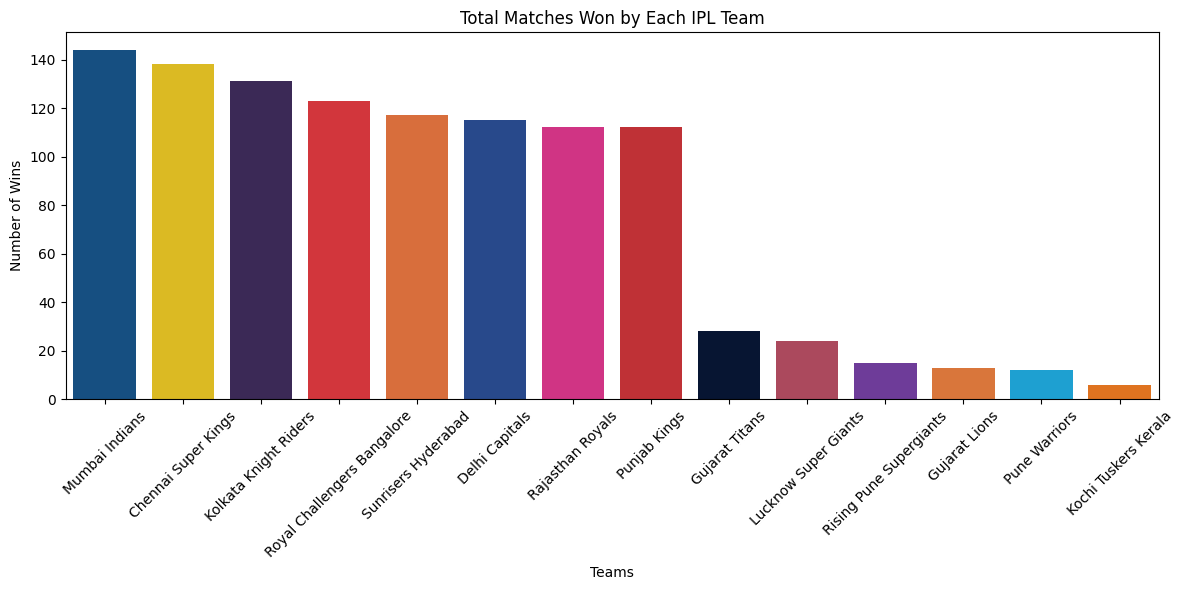

In [92]:
plt.figure(figsize=(12, 6))

sns.barplot(x=team_wins.index, y=team_wins.values,
            palette=[team_colours.get(team, "#808080") for team in team_wins.index])

plt.title("Total Matches Won by Each IPL Team")
plt.xlabel("Teams")
plt.ylabel("Number of Wins")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




# Insight: Most No. of Wins
This chart shows the total number of matches won by each IPL team. Teams such as Mumbai Indians and Chennai Super Kings appear among the most successful, indicating strong and consistent performance across multiple seasons.

Toss Winner vs Match Winner Analysis

In [93]:
# Create a new column to indicate if the team that won the toss also won the match
matches_clean["toss_match_win"] = (matches_clean["toss_winner"] == matches_clean["winner"])

In [94]:
# Count results where the toss winner also won the match
toss_results = matches_clean["toss_match_win"].value_counts()
toss_results


toss_match_win
True     554
False    536
Name: count, dtype: int64

In [95]:
# Calculate the percentage of matches where the toss winner also won the match
toss_percentage = (matches_clean["toss_match_win"].value_counts(normalize=True) * 100).round(2)
toss_percentage

toss_match_win
True     50.83
False    49.17
Name: proportion, dtype: float64

C:\Users\User\AppData\Local\Temp\ipykernel_40004\3138757600.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=toss_results.index.astype(str),


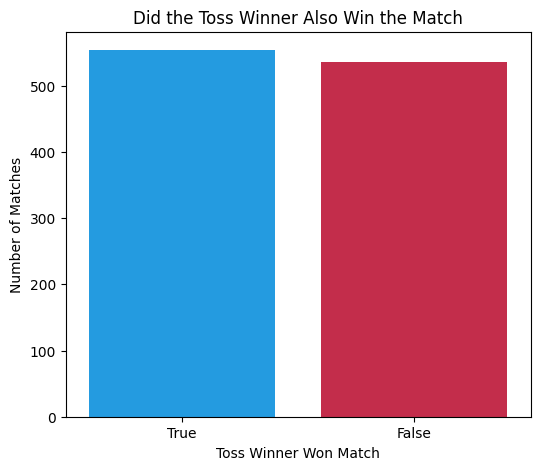

In [96]:
# Plotting the results
plt.figure(figsize=(6, 5))

sns.barplot(x=toss_results.index.astype(str),
            y=toss_results.values,
            palette=["#05A3FF", "#DC143C"])

plt.title("Did the Toss Winner Also Win the Match")
plt.xlabel("Toss Winner Won Match")
plt.ylabel("Number of Matches")

plt.show()

# Insight: Toss Winner and Match Outcome

The bars are similar in height, it suggests that winning the toss does not guarantee a match win. This analysis helps us understand whether the toss has a significant impact on the final result in IPL matches.

In [97]:
# Standardise Venues

venue_fixes = {
    "Wankhede Stadium": "Wankhede Stadium, Mumbai",
    "Eden Gardens": "Eden Gardens, Kolkata",
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium, Bengaluru",
    "M Chinnaswamy Stadium": "M Chinnaswamy Stadium, Bengaluru",
    "Feroz Shah Kotla": "Arun Jaitley Stadium, Delhi",
    "Arun Jaitley Stadium": "Arun Jaitley Stadium, Delhi",
    "MA Chidambaram Stadium": "MA Chidambaram Stadium, Chennai",
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium, Chennai",
    "MA Chidambaram Stadium, Chepauk, Chennai": "MA Chidambaram Stadium, Chennai",
    "Rajiv Gandhi International Stadium": "Rajiv Gandhi International Stadium, Hyderabad",
    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium, Hyderabad",
    "Rajiv Gandhi International Stadium, Uppal, Hyderabad": "Rajiv Gandhi International Stadium, Hyderabad",
    "Dr DY Patil Sports Academy": "Dr DY Patil Sports Academy, Mumbai",
    "Brabourne Stadium": "Brabourne Stadium, Mumbai",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "IS Bindra Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium": "IS Bindra Stadium, Mohali",
    "Punjab Cricket Association Stadium, Mohali": "IS Bindra Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh": "IS Bindra Stadium, Mohali",
    "Maharashtra Cricket Association Stadium": "Maharashtra Cricket Association Stadium, Pune",
    "Subrata Roy Sahara Stadium": "Maharashtra Cricket Association Stadium, Pune",
    "Sawai Mansingh Stadium": "Sawai Mansingh Stadium, Jaipur",
    "Sardar Patel Stadium, Motera": "Narendra Modi Stadium, Ahmedabad",
    "Sheikh Zayed Stadium": "Sheikh Zayed Stadium, Abu Dhabi",
    "Zayed Cricket Stadium, Abu Dhabi": "Sheikh Zayed Stadium, Abu Dhabi",
    " Sheikh Zayed Stadium, Abu Dhabi": "Sheikh Zayed Stadium, Abu Dhabi",
    "Dubai International Cricket Stadium": "Dubai International Cricket Stadium, Dubai",
    "Sharjah Cricket Stadium": "Sharjah Cricket Stadium, Sharjah",
    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam": "ACA-VDCA Cricket Stadium, Visakhapatnam",
    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium": "ACA-VDCA Cricket Stadium, Visakhapatnam",
    "SuperSport Park": "SuperSport Park, Centurion",
    "Saurashtra Cricket Association Stadium": "Saurashtra Cricket Association Stadium, Rajkot",
    "Himachal Pradesh Cricket Association Stadium": "Himachal Pradesh Cricket Association Stadium, Dharamshala",
    "Holkar Cricket Stadium": "Holkar Cricket Stadium, Indore",
    "New Wanderers Stadium": "Wanderers Stadium, Johannesburg",
    "Newlands": "Newlands Cricket Ground, Cape Town",
    "De Beers Diamond Oval": "De Beers Diamond Oval, Kimberley",
    "Vidarbha Cricket Association Stadium, Jamtha": "Vidarbha Cricket Association Stadium, Nagpur",
    "OUTsurance Oval": "Mangaung Oval, Bloemfontein",
    "Kingsmead": "Hollywoodbets Kingsmead Stadium, Durban",
    "Shaheed Veer Narayan Singh International Stadium": "Shaheed Veer Narayan Singh International Stadium, Raipur",
    "Nehru Stadium": "Jawaharlal Nehru Stadium, New Delhi",
    "Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur": "New International Cricket Stadium, New Chandigarh",
    "Buffalo Park": "Buffalo Park, East London",
    "Green Park": "Green Park Stadium, Kanpur",
    "St George's Park": "St George's Park, Gqeberha",
    "Barabati Stadium": "Barabati Stadium, Cuttack",
    "JSCA International Stadium Complex": "JSCA International Stadium Complex, Ranchi"
    }

# Top Venue Analysis

In [98]:
matches_clean["venue"] = matches_clean["venue"].replace(venue_fixes)
top_venues = matches_clean["venue"].value_counts()
top_20_venues = top_venues.head(22)
print(top_20_venues)

venue
Wankhede Stadium, Mumbai                                                 118
Eden Gardens, Kolkata                                                     93
M Chinnaswamy Stadium, Bengaluru                                          91
Arun Jaitley Stadium, Delhi                                               89
MA Chidambaram Stadium, Chennai                                           85
Rajiv Gandhi International Stadium, Hyderabad                             77
IS Bindra Stadium, Mohali                                                 61
Sawai Mansingh Stadium, Jaipur                                            57
Maharashtra Cricket Association Stadium, Pune                             51
Dubai International Cricket Stadium, Dubai                                46
Dr DY Patil Sports Academy, Mumbai                                        37
Sheikh Zayed Stadium, Abu Dhabi                                           37
Narendra Modi Stadium, Ahmedabad                                      

# Top 20 IPL Venues

C:\Users\User\AppData\Local\Temp\ipykernel_40004\3157057833.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


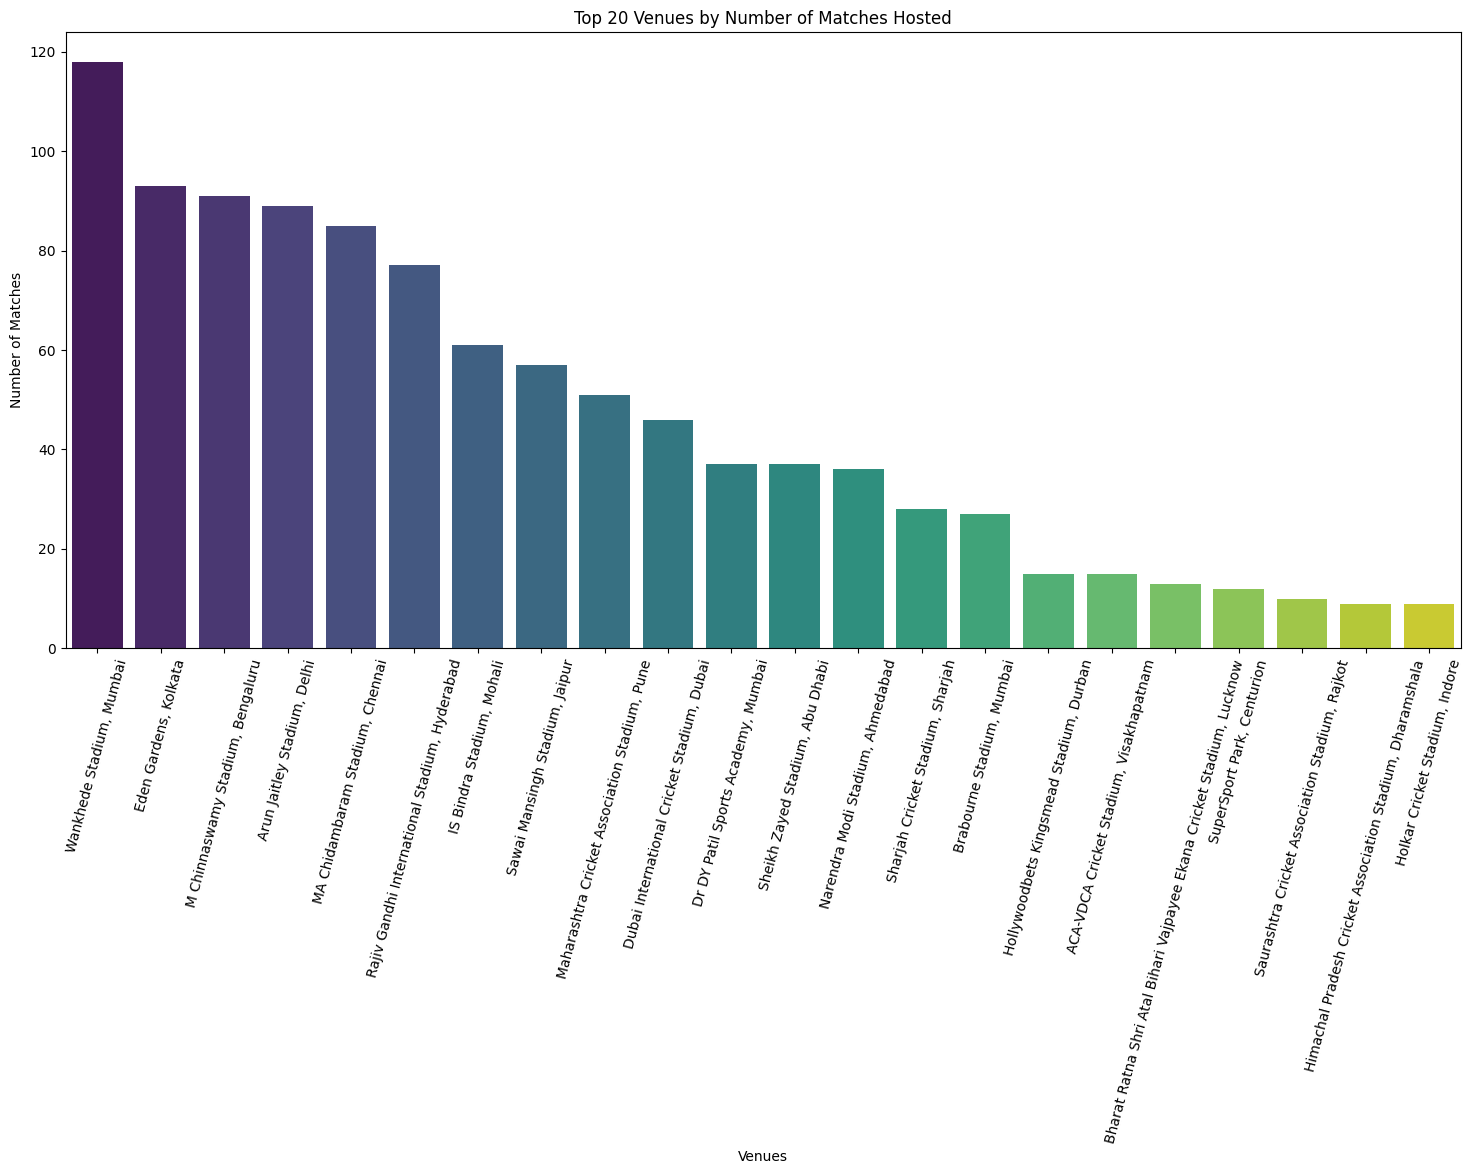

In [99]:
plt.figure(figsize=(18, 8))

sns.barplot(
    x=top_20_venues.index,
    y=top_20_venues.values,
    palette="viridis"
 )

plt.title("Top 20 Venues by Number of Matches Hosted")
plt.xlabel("Venues")
plt.ylabel("Number of Matches")

plt.xticks(rotation=75)

plt.show()

# Insight: Top IPL Venues Hosted

This chart highlights the IPL venues that have hosted the highest number of matches. Stadiums such as Wankhede Stadium and Eden Gardens appear frequently due to being long-term home grounds and regular hosts of major IPL fixtures. Venues located in the UAE and South Africa also appear due to political circumstances and the relocation of IPL seasons during the COVID-19 pandemic.

# Batting Analysis 

# 1️⃣ Top Run Scorers

In [100]:
deliveries_clean.columns.tolist()
top_runs = deliveries_clean.groupby("batter")["batsman_runs"].sum()
top_runs = top_runs.sort_values(ascending=False)
top_runs = top_runs.head(25)
top_runs


batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
KL Rahul          4689
AM Rahane         4642
F du Plessis      4571
SV Samson         4419
AT Rayudu         4348
G Gambhir         4217
SR Watson         3880
MK Pandey         3859
SA Yadav          3594
JC Buttler        3583
KA Pollard        3437
RR Pant           3297
YK Pathan         3222
Shubman Gill      3216
Q de Kock         3160
Name: batsman_runs, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_40004\588593454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


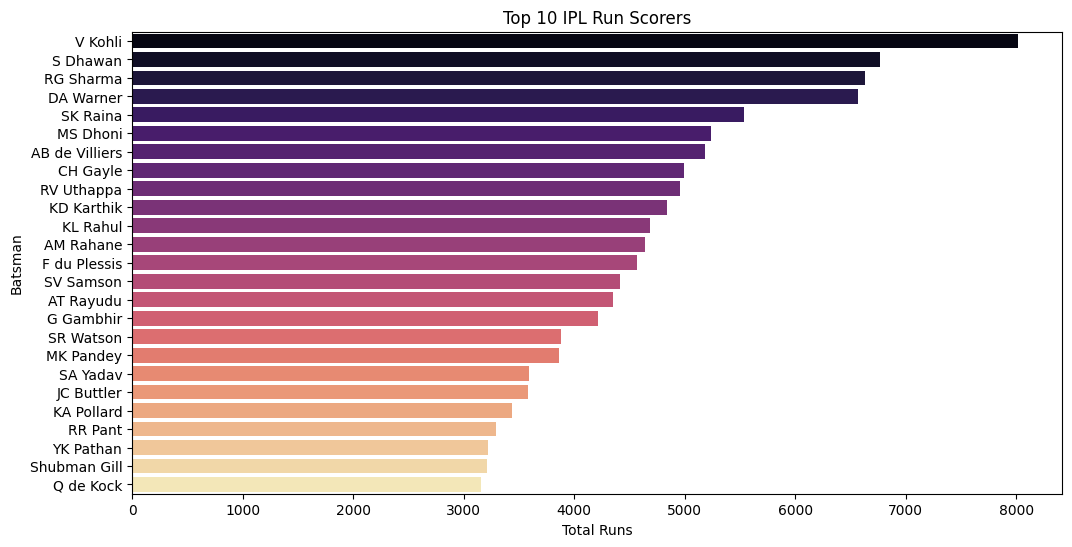

In [101]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_runs.values,
    y=top_runs.index,
    palette="magma"
)

plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Total Runs")
plt.ylabel("Batsman")

plt.show()

# Insight: Top IPL Run Scorers

This chart highlights the highest run scorers in IPL history. Players appearing near the top demonstrate long-term consistency, longevity and the ability to perform across multiple IPL seasons.

# 2️⃣ Strike Rate Analysis

In [102]:
deliveries_clean.columns.tolist()
batter_col = "batter"
runs_col = "batsman_runs"

In [103]:
batter_runs = deliveries_clean.groupby(batter_col)[runs_col].sum()
balls_faced = deliveries_clean.groupby(batter_col).size()

strike_rate_df = pd.DataFrame({
    "Runs": batter_runs,
    "Balls Faced": balls_faced
})

strike_rate_df["Strike Rate"] = (
    strike_rate_df["Runs"] / strike_rate_df["Balls Faced"]
) * 100

strike_rate_filtered = strike_rate_df[strike_rate_df["Balls Faced"] >= 500]

top_10_strike_rates = strike_rate_filtered.sort_values(
    by="Strike Rate",
    ascending=False
).head(10)

top_10_strike_rates


,Runs,Balls Faced,Strike Rate
batter,,,
AD Russell,2488,1515,164.224422
H Klaasen,993,613,161.990212
SP Narine,1534,984,155.894309
N Pooran,1769,1143,154.768154
LS Livingstone,939,609,154.187192
GJ Maxwell,2772,1842,150.488599
RM Patidar,799,534,149.625468
Abhishek Sharma,1377,925,148.864865
V Sehwag,2728,1833,148.827059


C:\Users\User\AppData\Local\Temp\ipykernel_40004\3938371163.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


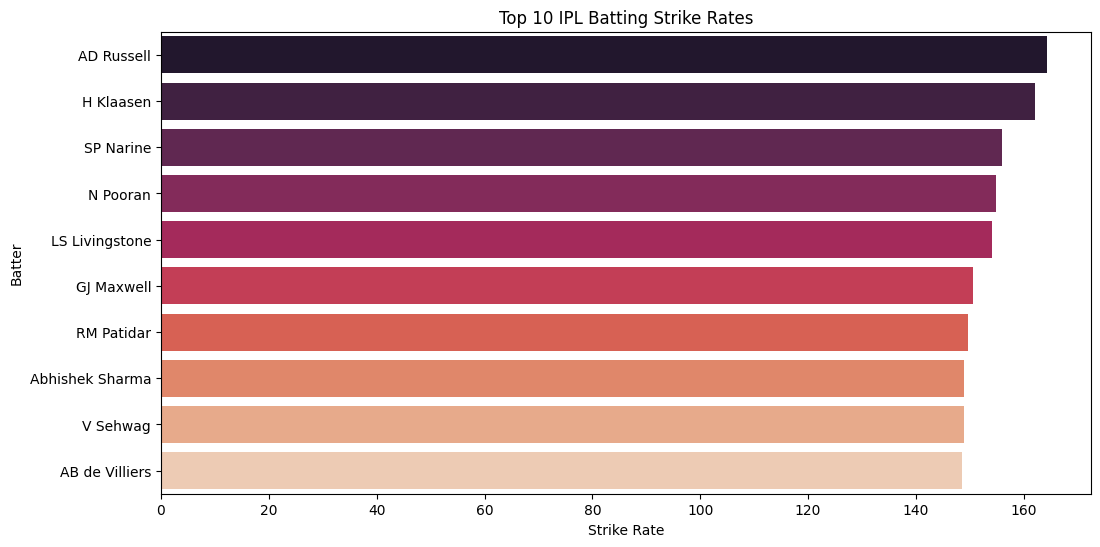

In [104]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_strike_rates["Strike Rate"],
    y=top_10_strike_rates.index,
    palette="rocket"
)

plt.title("Top 10 IPL Batting Strike Rates")
plt.xlabel("Strike Rate")
plt.ylabel("Batter")

plt.show()

# Insight: Top IPL Batting Strike Rate

This chart highlights the top 10 batsmen by strike rate among players who faced at least 500 balls are AD Russell, H Klaasen, SP Narine, N Pooran, LS Livingstone, GJ Maxwell, RM Patidar, Abhishek Sharma, V Sehwag, and AB de Villiers. This shows that these players were exceptionally aggressive and efficient scorers, converting deliveries into runs at a very high rate

# 3️⃣ Most Fours

In [105]:
fours = deliveries_clean[deliveries_clean["batsman_runs"] == 4]

most_fours = fours.groupby("batter").size()

most_fours = most_fours.sort_values(ascending=False)

top_10_fours = most_fours.head(10)
top_10_fours

batter
S Dhawan        768
V Kohli         708
DA Warner       663
RG Sharma       599
SK Raina        506
G Gambhir       492
RV Uthappa      481
AM Rahane       479
KD Karthik      466
F du Plessis    422
dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_40004\4215311430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


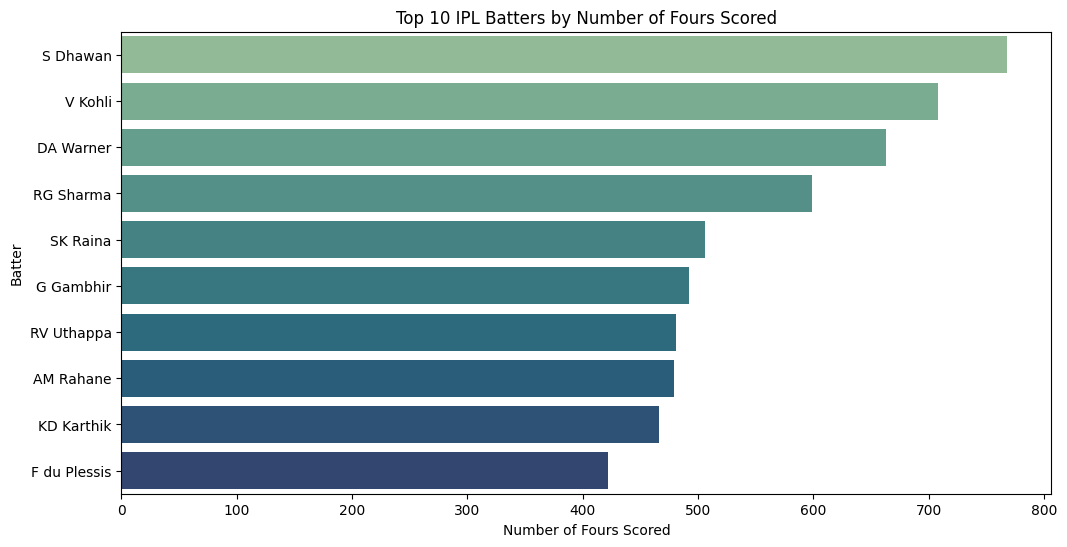

In [106]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_fours.values,
    y=top_10_fours.index,
    palette="crest"
)

plt.title("Top 10 IPL Batters by Number of Fours Scored")
plt.xlabel("Number of Fours Scored")
plt.ylabel("Batter")

plt.show()

# Insight: Most Fours in IPL History

This chart highlights the batters who have hit the most fours in IPL history. Players near the top of the rankings have consistently found gaps in the field and accumulated runs through timing and placement rather than relying solely on power hitting.

# 4️⃣ Most Sixes

In [107]:
sixes = deliveries_clean[deliveries_clean["batsman_runs"] == 6]

most_sixes = sixes.groupby("batter").size()

most_sixes = most_sixes.sort_values(ascending=False)

top_10_sixes = most_sixes.head(10)
top_10_sixes

batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_40004\399369714.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


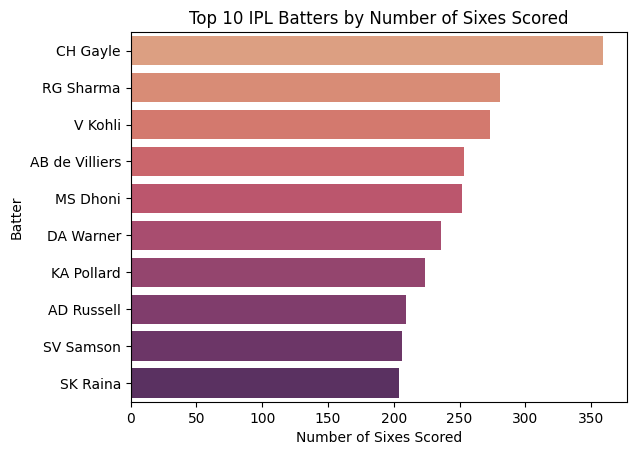

In [108]:
plt.Figure(figsize=(12, 6))

sns.barplot(
    x=top_10_sixes.values,
    y=top_10_sixes.index,
    palette="flare"
)

plt.title("Top 10 IPL Batters by Number of Sixes Scored")
plt.xlabel("Number of Sixes Scored")
plt.ylabel("Batter")

plt.show()

# Insight: Most Sixes in IPL History

This chart highlights the batters who have hit the most sixes in IPL history. Players near the top of the rankings are strong power hitters who consistently clear the boundary and accelerate scoring in T20 cricket.

# Highest Individual Scores

In [109]:
matches_clean.columns.tolist()


['id',
 'season',
 'city',
 'date',
 'match_type',
 'player_of_match',
 'venue',
 'team1',
 'team2',
 'toss_winner',
 'toss_decision',
 'winner',
 'result',
 'result_margin',
 'target_runs',
 'target_overs',
 'super_over',
 'method',
 'umpire1',
 'umpire2',
 'toss_match_win']

In [110]:
innings_scores = (
    deliveries_clean
    .groupby(["match_id", "batter"])["batsman_runs"]
    .sum()
    .reset_index()
)

matches_context = matches_clean[["id", "date", "team1", "team2", "venue"]].rename(
    columns={"id": "match_id"}
)

highest_scores = innings_scores.merge(
    matches_context,
    on="match_id",
    how="left"
)

highest_scores["Fixture"] = (
    highest_scores["team1"] + " vs " + highest_scores["team2"]
)

highest_scores = highest_scores.rename(
    columns={"batsman_runs": "Runs"}
)

top_10_highest_scores = (
    highest_scores
    .sort_values(by="Runs", ascending=False)
    .head(10)
)

top_10_highest_scores[["batter", "Runs", "Fixture", "venue"]]

,batter,Runs,Fixture,venue
5302,CH Gayle,175,Royal Challengers Bangalore vs Pune Warriors,"M Chinnaswamy Stadium, Bengaluru"
2,BB McCullum,158,Royal Challengers Bangalore vs Kolkata Knight ...,"M Chinnaswamy Stadium, Bengaluru"
14108,Q de Kock,140,Lucknow Super Giants vs Kolkata Knight Riders,"Dr DY Patil Sports Academy, Mumbai"
7528,AB de Villiers,133,Mumbai Indians vs Royal Challengers Bangalore,"Wankhede Stadium, Mumbai"
11583,KL Rahul,132,Punjab Kings vs Royal Challengers Bangalore,"Dubai International Cricket Stadium, Dubai"
15383,Shubman Gill,129,Gujarat Titans vs Mumbai Indians,"Narendra Modi Stadium, Ahmedabad"
8359,AB de Villiers,129,Royal Challengers Bangalore vs Gujarat Lions,"M Chinnaswamy Stadium, Bengaluru"
4687,CH Gayle,128,Delhi Capitals vs Royal Challengers Bangalore,"Arun Jaitley Stadium, Delhi"
10149,RR Pant,128,Delhi Capitals vs Sunrisers Hyderabad,"Arun Jaitley Stadium, Delhi"
2237,M Vijay,127,Chennai Super Kings vs Rajasthan Royals,"MA Chidambaram Stadium, Chennai"


C:\Users\User\AppData\Local\Temp\ipykernel_40004\599066882.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


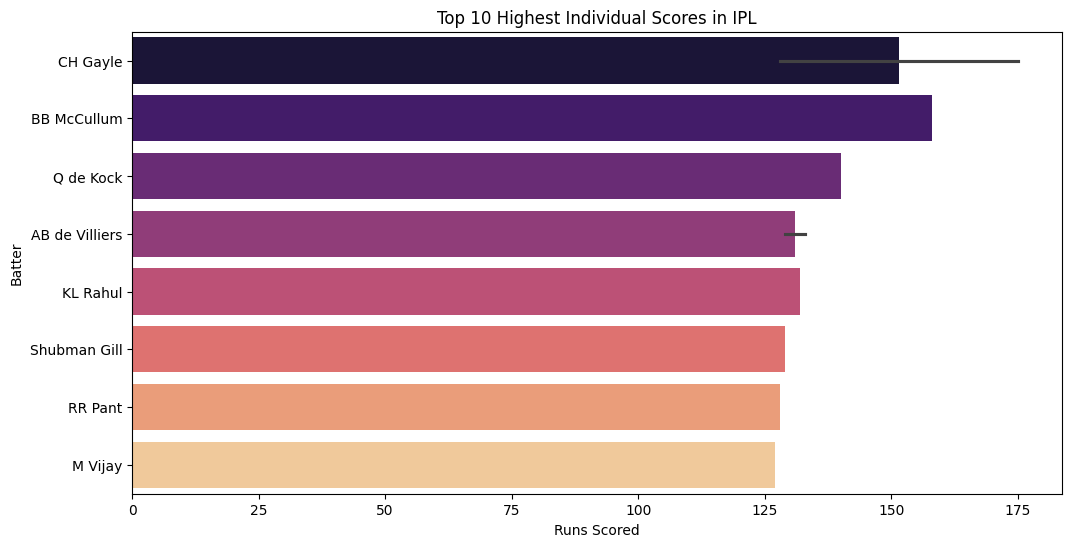

In [111]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_highest_scores["Runs"],
    y=top_10_highest_scores["batter"],
    palette="magma"
)

plt.title("Top 10 Highest Individual Scores in IPL")
plt.xlabel("Runs Scored")
plt.ylabel("Batter")

plt.show()

# Insight: Highest Individual Scores

The highest individual scores in IPL history are dominated by explosive top-order batters, who have the opportunity to face more deliveries. These innings often combine a high strike rate with sustained scoring throughout the innings, resulting in match-winning performances.

# Bowling Analysis

# 1️⃣ Top Wicket Takers

In [112]:
deliveries_clean.columns.tolist()

['match_id',
 'inning',
 'batting_team',
 'bowling_team',
 'over',
 'ball',
 'batter',
 'bowler',
 'non_striker',
 'batsman_runs',
 'extra_runs',
 'total_runs',
 'extras_type',
 'is_wicket',
 'player_dismissed',
 'dismissal_kind',
 'fielder']

In [113]:
bowler_wickets = deliveries_clean[
    deliveries_clean["dismissal_kind"].isin([
        "bowled",
        "caught",
        "lbw", 
        "stumped", 
        "caught and bowled", 
        "hit wicket"
    ])
]

top_wickets = (
    bowler_wickets
    .groupby("bowler")
    .size()
    .sort_values(ascending=False)
)

top_10_wickets = top_wickets.head(10)
top_10_wickets


bowler
YS Chahal     205
PP Chawla     192
DJ Bravo      183
B Kumar       181
R Ashwin      180
SP Narine     180
A Mishra      174
SL Malinga    170
JJ Bumrah     168
RA Jadeja     160
dtype: int64

In [114]:
top_10_wickets_table = (
    top_10_wickets
    .reset_index(name="wickets")
)

top_10_wickets_table

,bowler,wickets
0,YS Chahal,205
1,PP Chawla,192
2,DJ Bravo,183
3,B Kumar,181
4,R Ashwin,180
5,SP Narine,180
6,A Mishra,174
7,SL Malinga,170
8,JJ Bumrah,168
9,RA Jadeja,160


C:\Users\User\AppData\Local\Temp\ipykernel_40004\915976422.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


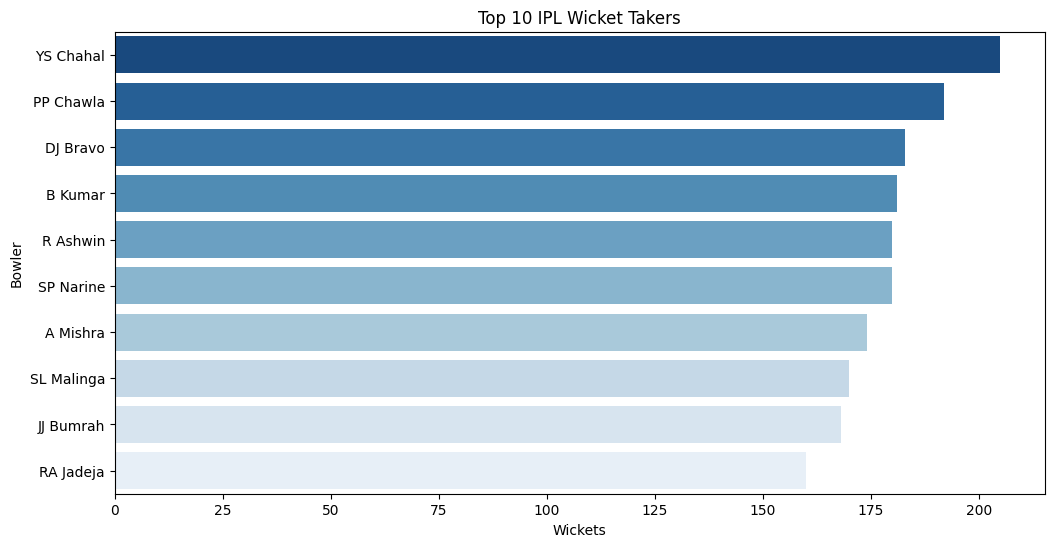

In [115]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_wickets.values,
    y=top_10_wickets.index,
    palette="Blues_r"
)

plt.title("Top 10 IPL Wicket Takers")
plt.xlabel("Wickets")
plt.ylabel("Bowler")

plt.show()

# Insight: Top IPL Wicket Takers

This chart highlights the bowlers with the most wickets in IPL history. The rankings include only dismissals officially credited to the bowler, excluding run outs, retired hurt, retired out and obstructing the field. The leading bowlers have demonstrated consistency, longevity and the ability to take wickets across multiple IPL seasons.

# 2️⃣ Economy Rate

In [116]:
# Inspect the extra types in the dataset
deliveries_clean["extras_type"].value_counts(dropna=False)

extras_type
NaN        246795
wides        8380
legbyes      4001
noballs      1069
byes          673
penalty         2
Name: count, dtype: int64

In [117]:
# Calculate runs charged to the bowler
# Byes and leg byes are not charged to the bowler
deliveries_clean["bowler_runs_conceded"] = np.where(
    deliveries_clean["extras_type"].isin(["byes", "legbyes"]),
    deliveries_clean["batsman_runs"],
    deliveries_clean["total_runs"]
)

# Mark legal deliveries
# Wides and no-balls do not count as legal balls
deliveries_clean["legal_delivery"] = ~deliveries_clean[
    "extras_type"
].isin(["wides", "noballs"])

# Aggregate each bowler's runs conceded and legal deliveries
bowling_economy = (
    deliveries_clean
    .groupby("bowler")
    .agg(
        runs_conceded=("bowler_runs_conceded", "sum"),
        legal_balls=("legal_delivery", "sum")
    )
    .reset_index()
)

# Convert legal balls into mathematical overs
bowling_economy["overs_bowled"] = (
    bowling_economy["legal_balls"] / 6
)

# Calculate economy rate
bowling_economy["economy_rate"] = (
    bowling_economy["runs_conceded"] * 6 
    / bowling_economy["legal_balls"]
)

# Keep bowlers who have bowled at least 50 overs
qualified_bowlers = bowling_economy[
    bowling_economy["legal_balls"] >= 300
].copy()

# Select the 10 lowest economy rates
top_economy_bowlers = (
    qualified_bowlers
    .sort_values("economy_rate", ascending=True)
    .head(10)
)

top_economy_bowlers["economy_rate"] = (
    top_economy_bowlers["economy_rate"].round(2)
)

top_economy_bowlers["overs_bowled"] = (
    top_economy_bowlers["overs_bowled"].round(2)
)

# Display the results
top_economy_bowlers[
    ["bowler", "economy_rate", "overs_bowled", "runs_conceded"]
]


,bowler,economy_rate,overs_bowled,runs_conceded
7,A Kumble,6.58,160.83,1058
147,GD McGrath,6.61,54.00,357
263,M Muralitharan,6.70,254.67,1706
446,SP Narine,6.74,680.17,4582
377,RE van der Merwe,6.74,73.83,498
130,DL Vettori,6.79,129.50,879
398,Rashid Khan,6.83,478.67,3267
181,J Yadav,6.85,65.00,445
176,J Botha,6.92,115.67,800
284,MJ Santner,6.92,61.00,422


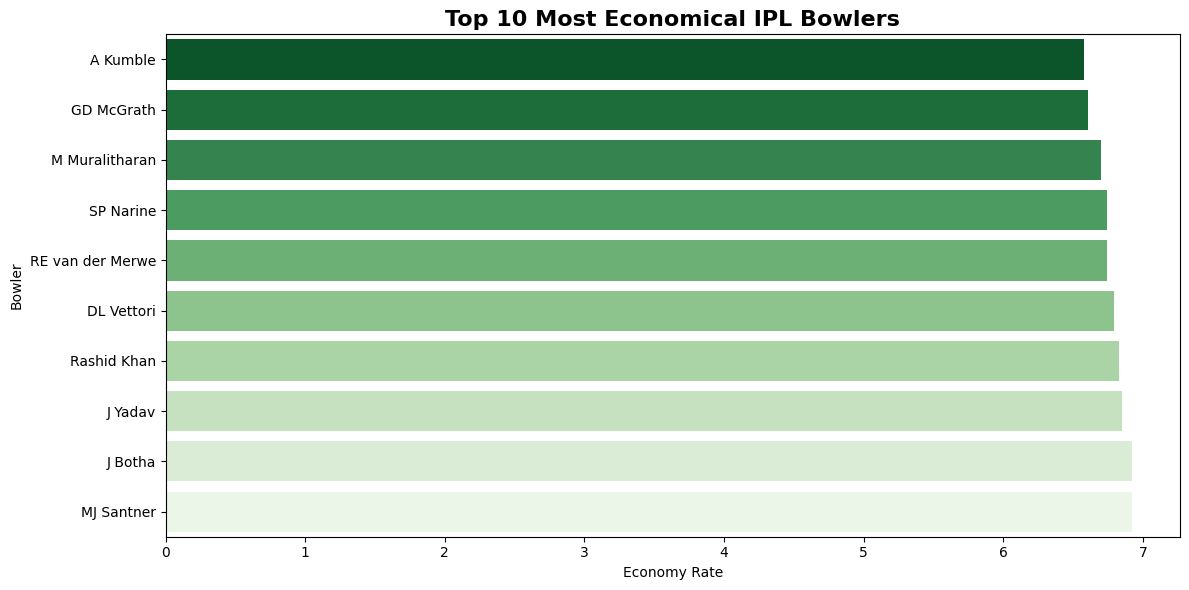

In [118]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_economy_bowlers,
    x="economy_rate",
    y="bowler",
    hue="bowler",
    palette="Greens_r",
    legend=False
)

plt.title(
    "Top 10 Most Economical IPL Bowlers",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Economy Rate")
plt.ylabel("Bowler")

plt.tight_layout()
plt.show()

# Insight: Top 10 Most Economical Bowlers

SP Narine and Rashid Khan stand out most: they combine low economy rates (6.74 and 6.83) with large workloads—680 and 479 overs—showing sustained control across many IPL matches.  
A Kumble has the best economy rate (6.58), while GD McGrath’s 6.61 is impressive but based on the minimum qualifying workload of 54 overs.


# 3️⃣Best Bowling Figures

In [119]:
# Define valid wickets
valid_bowler_wickets = [
    "bowled",
    "caught",
    "lbw",
    "stumped",
    "caught and bowled",
    "hit wicket"
]

deliveries_clean["bowler_wicket"] = (
    deliveries_clean["dismissal_kind"].isin(valid_bowler_wickets)
    .astype(int)
)


In [120]:
# Calculate bowling figures for each match
match_bowling_figures = (
    deliveries_clean
    .groupby(["match_id", "bowler"])
    .agg(
        wickets=("bowler_wicket", "sum"),
        runs_conceded=("bowler_runs_conceded", "sum")
    )
    .reset_index()
)

match_bowling_figures = match_bowling_figures[
    match_bowling_figures["wickets"] > 0
].copy()

In [121]:
# Rank the best performance
best_bowling_figures = (
    match_bowling_figures
    .sort_values(
        by=["wickets", "runs_conceded"],
        ascending=[False, True]
    )
    .head(10)
    .copy()
)

best_bowling_figures["figures"] = (
    best_bowling_figures["wickets"].astype(str)
    + "/"
    + best_bowling_figures["runs_conceded"].astype(str)
)

In [122]:
# Add match context
matches_context["fixture"] = (
    matches_context["team1"] + " vs " + matches_context["team2"]
)

best_bowling_figures = best_bowling_figures.merge(
    matches_context[
        ["match_id", "date", "fixture", "venue"]
    ],
    on="match_id",
    how="left"
)

# Display
best_bowling_figures[
    ["bowler", "figures", "date", "fixture", "venue"]
]

,bowler,figures,date,fixture,venue
0,AS Joseph,6/12,2019-04-06,Mumbai Indians vs Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Hyderabad"
1,Sohail Tanvir,6/14,2008-05-04,Rajasthan Royals vs Chennai Super Kings,"Sawai Mansingh Stadium, Jaipur"
2,A Zampa,6/19,2016-05-10,Rising Pune Supergiants vs Sunrisers Hyderabad,"ACA-VDCA Cricket Stadium, Visakhapatnam"
3,A Kumble,5/5,2009-04-18,Royal Challengers Bangalore vs Rajasthan Royals,"Newlands Cricket Ground, Cape Town"
4,Akash Madhwal,5/5,2023-05-24,Mumbai Indians vs Lucknow Super Giants,"MA Chidambaram Stadium, Chennai"
5,JJ Bumrah,5/10,2022-05-09,Kolkata Knight Riders vs Mumbai Indians,"Dr DY Patil Sports Academy, Mumbai"
6,MM Sharma,5/10,2023-05-26,Gujarat Titans vs Mumbai Indians,"Narendra Modi Stadium, Ahmedabad"
7,I Sharma,5/12,2011-04-27,Kochi Tuskers Kerala vs Sunrisers Hyderabad,"Jawaharlal Nehru Stadium, New Delhi"
8,SL Malinga,5/13,2011-04-10,Delhi Capitals vs Mumbai Indians,"Arun Jaitley Stadium, Delhi"
9,AS Rajpoot,5/14,2018-04-26,Sunrisers Hyderabad vs Punjab Kings,"Rajiv Gandhi International Stadium, Hyderabad"


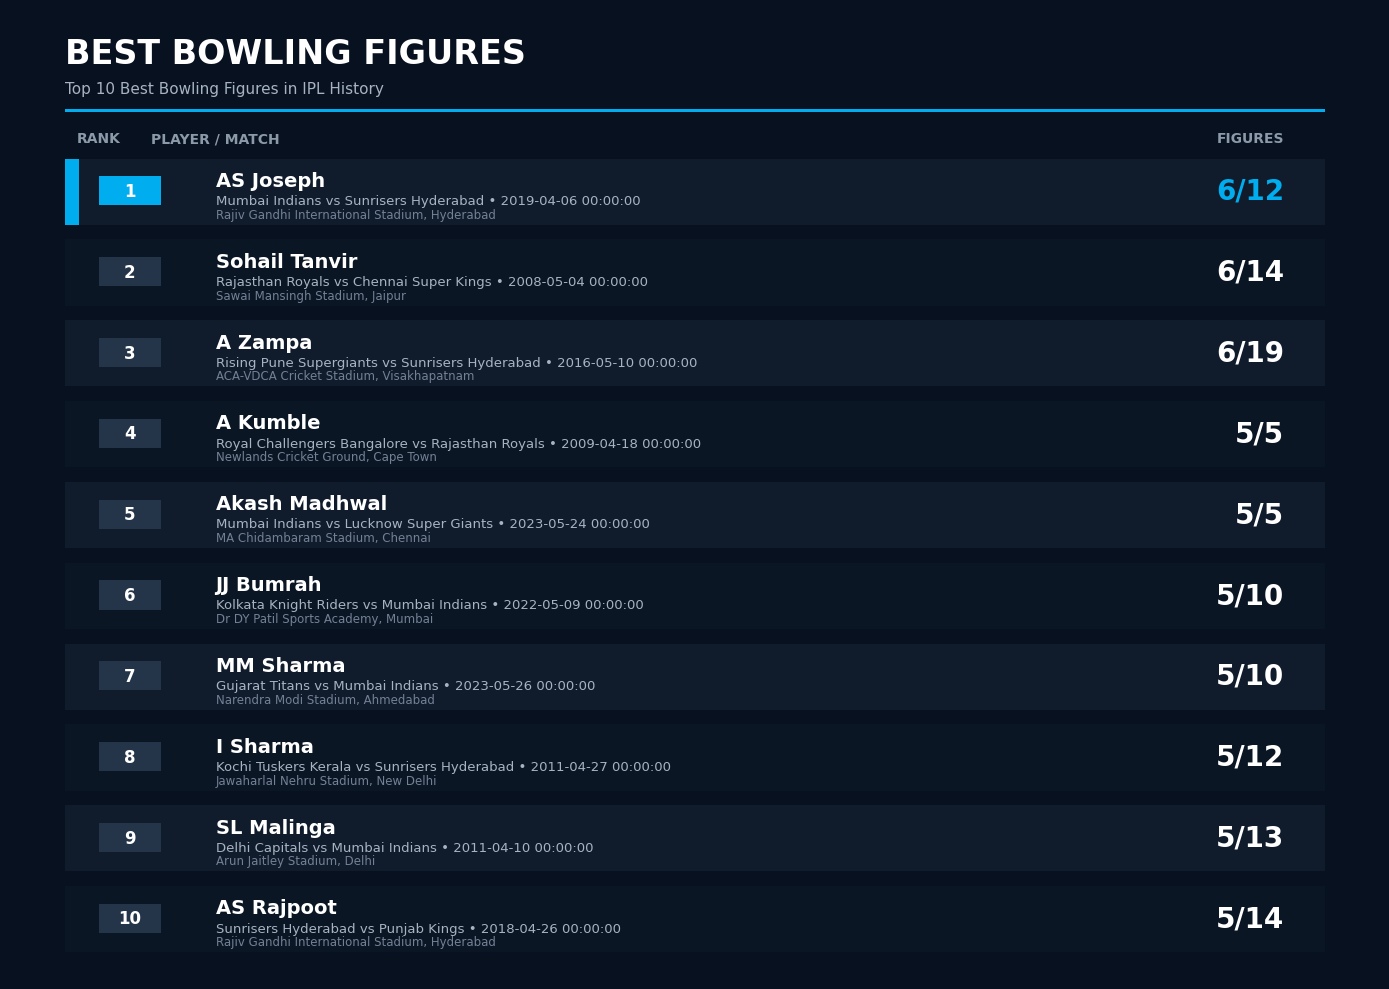

In [123]:
display_figures = best_bowling_figures.reset_index(drop=True).copy()

fig, ax = plt.subplots(figsize=(14, 10))

# Background colours
fig.patch.set_facecolor("#07111F")
ax.set_facecolor("#07111F")

ax.set_xlim(0, 1)
ax.set_ylim(0, len(display_figures) + 2)
ax.axis("off")

# Title
ax.text(
    0.04,
    len(display_figures) + 1.45,
    "BEST BOWLING FIGURES",
    fontsize=24,
    fontweight="bold",
    color="white",
    va="center"
)

# Subtitle
ax.text(
    0.04,
    len(display_figures) + 1.02,
    "Top 10 Best Bowling Figures in IPL History",
    fontsize=11,
    color="#A8B3C2",
    va="center"
)

# Top accent line
ax.add_patch(
    Rectangle(
        (0.04, len(display_figures) + 0.72),
        0.92,
        0.04,
        color="#00AEEF",
        linewidth=0
    )
)

# Column headings
ax.text(
    0.065,
    len(display_figures) + 0.35,
    "RANK",
    fontsize=10,
    fontweight="bold",
    color="#8C99A8",
    ha="center"
)

ax.text(
    0.15,
    len(display_figures) + 0.35,
    "PLAYER / MATCH",
    fontsize=10,
    fontweight="bold",
    color="#8C99A8",
    ha="center"
)

ax.text(
    0.93,
    len(display_figures) + 0.35,
    "FIGURES",
    fontsize=10,
    fontweight="bold",
    color="#8C99A8",
    ha="right"
)

for i, row in display_figures.iterrows():

    y = len(display_figures) - i - 0.25

    # Alternating row backgrounds
    row_colour = "#101C2C" if i % 2 == 0 else "#0B1624"

    ax.add_patch(
        Rectangle(
            (0.04, y - 0.42),
            0.92,
            0.82,
            facecolor=row_colour,
            edgecolor="none"
        )
    )

    # Highlight first place
    if i ==0:
        ax.add_patch(
            Rectangle(
                (0.04, y - 0.42),
                0.01,
                0.82,
                facecolor="#00AEEF",
                edgecolor="none",
            )
        )

    # Rank badge
    badge_colour = "#00AEEF" if i == 0 else "#243449"

    ax.add_patch(
        Rectangle(
            (0.065, y - 0.18),
            0.045,
            0.36,
            facecolor=badge_colour,
            edgecolor="none"
        )
    )

    ax.text(
        0.0875,
        y,
        str(i + 1),
        fontsize=12,
        fontweight="bold",
        color="white",
        ha="center",
        va="center"
    )

    # Bowler name
    ax.text(
        0.15,
        y + 0.13,
        row["bowler"],
        fontsize=14,
        fontweight="bold",
        color="white",
        va="center"
    )

    # Fixture
    fixture_text = f'{row["fixture"]} • {row["date"]}'

    ax.text(
        0.15,
        y - 0.12,
        fixture_text,
        fontsize=9.5,
        color="#A8B3C2",
        va="center"
    )

    # Venue
    ax.text(
        0.15,
        y - 0.29,
        row["venue"],
        fontsize=8.5,
        color="#738196",
        va="center"
    )

    # Bowling Figures
    ax.text(
        0.93,
        y,
        row["figures"],
        fontsize=20,
        fontweight="bold",
        color="#00AEEF" if i == 0 else "white",
        ha="right",
        va="center"
    )

plt.tight_layout()
plt.show()



# Insight: Top 10 Best Bowling Figures

S Joseph’s 6/12 is the standout performance: it is the only six-wicket haul with the fewest runs conceded among the six-wicket entries.  
The graph also shows the ranking prioritises wickets: A Kumble and Akash Madhwal’s exceptional 5/5 figures are the most economical, but they appear below the six-wicket hauls because they took one fewer wicket.

# 4️⃣ Best Bowling Average

In [124]:
deliveries_clean[
    ["bowler", "bowler_runs_conceded", "bowler_wicket"]
].head()

bowling_average = (
    deliveries_clean
    .groupby("bowler")
    .agg(
        runs_conceded=("bowler_runs_conceded", "sum"),
        wickets=("bowler_wicket", "sum")
        )
        .reset_index()
    )

bowling_average = bowling_average[
    bowling_average["wickets"] > 0
].copy()

bowling_average["bowling_average"] = (
    bowling_average["runs_conceded"] / bowling_average["wickets"]
)

qualified_bowling_avg = bowling_average[
    bowling_average["wickets"] >= 50
].copy()

top_bowling_avg = (
    qualified_bowling_avg
    .sort_values("bowling_average", ascending=True)
    .head(10)
    .copy()
)

top_bowling_avg[["bowler", "wickets", "runs_conceded", "bowling_average"]]

,bowler,wickets,runs_conceded,bowling_average
438,SL Malinga,170,3371,19.829412
174,Imran Tahir,82,1703,20.768293
212,K Rabada,120,2577,21.475000
398,Rashid Khan,149,3267,21.926174
193,JJ Bumrah,168,3743,22.279762
273,MA Starc,51,1137,22.294118
524,YS Chahal,205,4602,22.448780
289,MM Patel,74,1698,22.945946
29,AD Russell,115,2646,23.008696
162,HV Patel,135,3148,23.318519


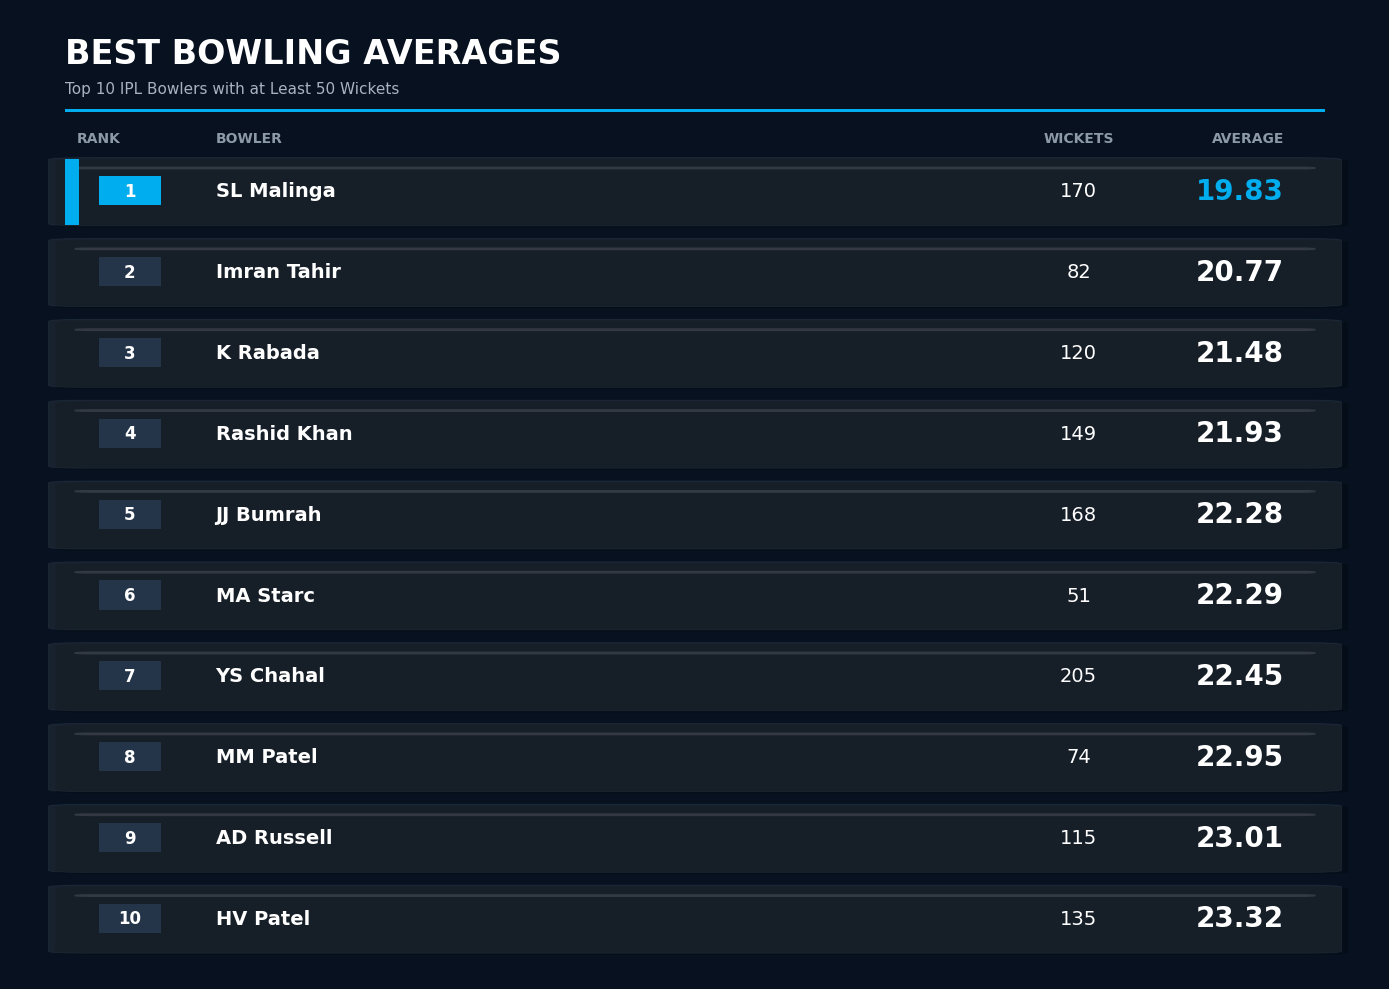

In [125]:
display_avg = top_bowling_avg.reset_index(drop=True).copy()

fig, ax = plt.subplots(figsize=(14, 10))

fig.patch.set_facecolor("#07111F")
ax.set_facecolor("#07111F")

ax.set_xlim(0, 1)
ax.set_ylim(0, len(display_avg) + 2)
ax.axis("off")

ax.text(
    0.04, len(display_avg) + 1.45,
    "BEST BOWLING AVERAGES",
    fontsize=24, fontweight="bold",
    color="white", va="center"
)

ax.text(
    0.04, len(display_avg) + 1.02,
    "Top 10 IPL Bowlers with at Least 50 Wickets",
    fontsize=11, color="#A8B3C2", va="center"
)

ax.add_patch(
    Rectangle(
        (0.04, len(display_avg) + 0.72),
        0.92, 0.04,
        color="#00AEEF",
        linewidth=0
    )
)

ax.text(0.065, len(display_avg) + 0.35, "RANK",
        fontsize=10, fontweight="bold", color="#8C99A8", ha="center")

ax.text(0.15, len(display_avg) + 0.35, "BOWLER",
        fontsize=10, fontweight="bold", color="#8C99A8")

ax.text(0.78, len(display_avg) + 0.35, "WICKETS",
        fontsize=10, fontweight="bold", color="#8C99A8", ha="center")

ax.text(0.93, len(display_avg) + 0.35, "AVERAGE",
        fontsize=10, fontweight="bold", color="#8C99A8", ha="right")

for i, row in display_avg.iterrows():

    y = len(display_avg) - i - 0.25

    # Soft shadow behind the card
    ax.add_patch(
        FancyBboxPatch(
            (0.045, y - 0.44), 0.92, 0.82,
            boxstyle="round,pad=0.012,rounding_size=0.025",
            facecolor="#000000", alpha=0.20, edgecolor="none"
        )
    )

    # Translucent frosted-glass card
    ax.add_patch(
        FancyBboxPatch(
            (0.04, y - 0.42), 0.92, 0.82,
            boxstyle="round,pad=0.012,rounding_size=0.025",
            facecolor="#FFFFFF", alpha=0.07,
            edgecolor="#8DCFF0", linewidth=0.7
        )
    )

    # Subtle highlight across the top of the glass
    ax.add_patch(
        FancyBboxPatch(
            (0.052, y + 0.27), 0.896, 0.025,
            boxstyle="round,pad=0.005,rounding_size=0.01",
            facecolor="#FFFFFF", alpha=0.12, edgecolor="none"
        )
    )

    if i == 0:
        ax.add_patch(
            Rectangle(
                (0.04, y - 0.42), 0.01, 0.82,
                facecolor="#00AEEF", edgecolor="none"
            )
        )

    badge_colour = "#00AEEF" if i == 0 else "#243449"

    ax.add_patch(
        Rectangle(
            (0.065, y - 0.18), 0.045, 0.36,
            facecolor=badge_colour, edgecolor="none"
        )
    )

    ax.text(0.0875, y, str(i + 1),
            fontsize=12, fontweight="bold",
            color="white", ha="center", va="center")

    ax.text(0.15, y, row["bowler"],
            fontsize=14, fontweight="bold",
            color="white", va="center")

    ax.text(0.78, y, f'{int(row["wickets"])}',
            fontsize=14, color="white",
            ha="center", va="center")

    ax.text(0.93, y, f'{row["bowling_average"]:.2f}',
            fontsize=20, fontweight="bold",
            color="#00AEEF" if i == 0 else "white",
            ha="right", va="center")

plt.tight_layout()
plt.show()

# Insight: Top 10 Bowling Averages

Lasith Malinga has the best bowling average among qualified bowlers, conceding only 19.83 runs per wicket across 170 wickets.  
YS Chahal is especially notable: although his average is slightly higher at 22.45, he has taken the most wickets in the top 10 (205), showing elite performance over a very large IPL workload.

# Team Analysis

# 1️⃣ Highest Team Totals

In [126]:
deliveries_clean[
    ["match_id", "inning", "batting_team", "bowling_team","total_runs"]
].head()

,match_id,inning,batting_team,bowling_team,total_runs
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0


In [127]:
# Wicket Info 
deliveries_clean[
    ["player_dismissed", "dismissal_kind"]
].head()

valid_team_wickets = [
    "bowled",
    "caught",
    "lbw",
    "stumped",
    "caught and bowled",
    "hit wicket",
    "run out",
    "obstructing the field",
    "hit the ball twice",
    "retired out"
]


In [128]:
deliveries_clean["team_wicket"] = (
    deliveries_clean["dismissal_kind"]
    .isin(valid_team_wickets)
    .astype(int)
)

In [129]:
# Recalculate inning total with wickets

team_innings_totals = (
    deliveries_clean.groupby(
        ["match_id", "inning", "batting_team"],
        as_index=False
    )
    .agg(
        team_total=("total_runs", "sum"),
        wickets_lost=("team_wicket", "sum"),
        opposition=("bowling_team", "first")
    )
)

In [130]:
# Score
team_innings_totals["score"] = np.where(
    team_innings_totals["wickets_lost"] >= 10,
    team_innings_totals["team_total"].astype(str),
    (
        team_innings_totals["team_total"].astype(str)
        + "/" + team_innings_totals["wickets_lost"].astype(str)
    )
)

In [131]:
# Match Context

matches_context = matches_clean[
    ["id", "date", "venue"]
].rename(
    columns={"id": "match_id"}
)

team_innings_totals = team_innings_totals.merge(
    matches_context,
    on="match_id",
    how="left"
)


In [132]:
# Rank highest totals
highest_team_totals = (
    team_innings_totals
    .sort_values(
        by="team_total",
        ascending=False
    )
    .head(10)
    .copy()
)

highest_team_totals = (
    highest_team_totals
    .reset_index(drop=True)
)

In [133]:
# Display Results
highest_team_totals[
    [
        "batting_team",
        "score",
        "opposition",
        "date",
        "venue",
        "team_total"
    ]
]

display_totals = highest_team_totals.reset_index(drop=True).copy()
display_totals["date"] = pd.to_datetime(
    display_totals["date"]
).dt.strftime("%d/%m/%Y")

In [134]:
# Visualisation

team_colours = {
    "Mumbai Indians": "#045093",
    "Chennai Super Kings": "#F9CD05",
    "Kolkata Knight Riders": "#3A225D",
    "Royal Challengers Bangalore": "#EC1C24",
    "Sunrisers Hyderabad": "#F26522",
    "Delhi Capitals": "#17449B",
    "Rajasthan Royals": "#EA1A85",
    "Punjab Kings": "#D71920",
    "Gujarat Titans": "#1C1C3C",
    "Lucknow Super Giants": "#F22854",
    "Gujarat Lions": "#F37021",
    "Rising Pune Supergiants": "#6F2DA8",
    "Pune Warriors": "#00AEEF",
    "Kochi Tuskers Kerala": "#FF6F00"
}

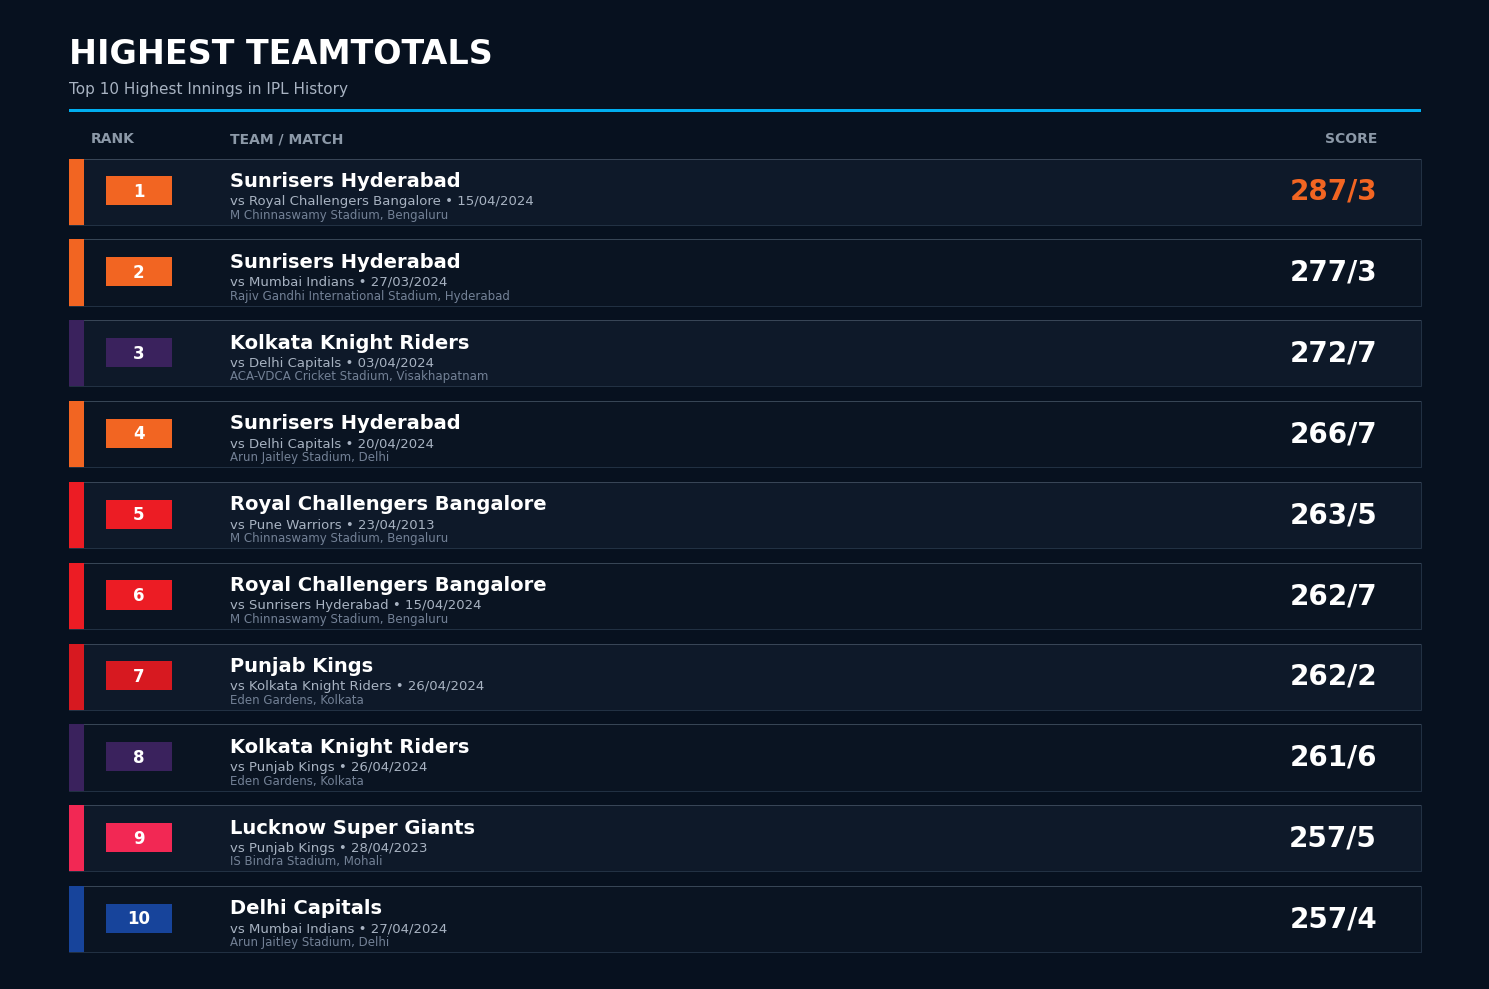

In [135]:
fig, ax = plt.subplots(figsize=(15, 10))

# Broadcast-style dark background
fig.patch.set_facecolor("#07111F")
ax.set_facecolor("#07111F")

ax.set_xlim(0, 1)
ax.set_ylim(0, len(display_totals) + 2)
ax.axis("off")

# Main Title
ax.text(
    0.04, len(display_totals) + 1.45,
    "HIGHEST TEAMTOTALS",
    fontsize=24, fontweight="bold",
    color="white", va="center"
)

# Subtitle
ax.text(
    0.04, len(display_totals) + 1.02,
    "Top 10 Highest Innings in IPL History",
    fontsize=11, color="#A8B3C2", va="center"
)

# Header Accent Line
ax.add_patch(
    Rectangle(
        (0.04, len(display_totals) + 0.72),
        0.92, 0.04,
        facecolor="#00AEEF",
        edgecolor="none"
    )
)

# Column Headings
ax.text(
    0.07, len(display_totals) + 0.35,
    "RANK",
    fontsize=10, 
    fontweight="bold", 
    color="#8C99A8", 
    ha="center"
)

ax.text(
    0.15,
    len(display_totals) + 0.35,
    "TEAM / MATCH",
    fontsize=10,
    fontweight="bold",
    color="#8C99A8"
)

ax.text(
    0.93,
    len(display_totals) + 0.35,
    "SCORE",
    fontsize=10,
    fontweight="bold",
    color="#8C99A8",
    ha="right"
)

# Draw Ranked Rows
for i, row in display_totals.iterrows():

    y = len(display_totals) - i - 0.25

    # Alternating glass-effect backgrounds
    row_colour = "#101C2C" if i % 2 == 0 else "#0B1624"

    ax.add_patch(
        Rectangle(
            (0.04, y - 0.42),
            0.92,
            0.82,
            facecolor=row_colour,
            alpha=0.78,
            edgecolor="#2A3A4E",
            linewidth=0.7
        )
    )

    # Subtle top-edge shine for a glass-like panel
    ax.add_patch(
        Rectangle(
            (0.04, y + 0.388),
            0.92,
            0.012,
            facecolor="white",
            alpha=0.10,
            edgecolor="none"
        )
    )

    # Team Colour
    team_colour = team_colours.get(
        row["batting_team"],
        "#00AEEF")

    # Team Colour Strip
    ax.add_patch(
        Rectangle(
            (0.04, y - 0.42),
            0.01,
            0.82,
            facecolor=team_colour,
            edgecolor="none"
        )
    )

    # Rank Badge
    ax.add_patch(
        Rectangle(
            (0.065, y - 0.18),
            0.045,
            0.36,
            facecolor=team_colour,
            edgecolor="none"
        )
    )

    ax.text(
        0.0875, 
        y,
        str(i + 1),
        fontsize=12, 
        fontweight="bold",
        color="white", 
        ha="center", 
        va="center"
    )

    # Team Name
    ax.text(
        0.15, 
        y + 0.13,
        row["batting_team"],
        fontsize=14, 
        fontweight="bold",
        color="white", 
        va="center"
    )

    # Fixture
    match_text = (
        f'vs {row["opposition"]} • {row["date"]}'
    )

    ax.text(
        0.15, 
        y - 0.12,
        match_text,
        fontsize=9.5, 
        color="#A8B3C2", 
        va="center"
    )

    # Venue
    ax.text(
        0.15, 
        y - 0.29,
        row["venue"],
        fontsize=8.5, 
        color="#738196", 
        va="center"
    )

    # Score
    ax.text(
        0.93, 
        y, 
        row["score"],
        fontsize=20, 
        fontweight="bold",
        color=team_colour if i == 0 else "white", 
        ha="right", 
        va="center"
    )

plt.tight_layout()
plt.show()

# Insight: Highest Team Totals

Eight of the top 10 innings were recorded in 2024. Sunrisers Hyderabad set the benchmark with 287/3 and occupy three of the top four spots


# 2️⃣ Highest Team Win %

In [136]:
# Count matches
team1_matches = matches_clean["team1"].value_counts()
team2_matches = matches_clean["team2"].value_counts()

matches_played = team1_matches.add(
    team2_matches,
    fill_value=0
)

# Count Wins
team_wins = matches_clean["winner"].value_counts()

# Combine matches & wins
team_win_percentage = pd.DataFrame({
    "Matches Played": matches_played,
    "Wins": team_wins
})

team_win_percentage["Wins"] = (
    team_win_percentage["Wins"]
    .fillna(0)
)

# Calculate Win Percentage
team_win_percentage["Win Percentage"] = (
    team_win_percentage["Wins"] 
    / team_win_percentage["Matches Played"]
) * 100

# Clean data types
team_win_percentage["Matches Played"] = (
    team_win_percentage["Matches Played"]
    .astype(int)
)

team_win_percentage["Wins"] = (
    team_win_percentage["Wins"]
    .astype(int)
)

team_win_percentage["Win Percentage"] = (
    team_win_percentage["Win Percentage"]
    .round(2)
)

# Reset Index
team_win_percentage = (
    team_win_percentage
    .reset_index()
    .rename(columns={"index": "Team"})
)

# Sort
team_win_percentage = (
    team_win_percentage
    .sort_values(
        "Win Percentage", 
        ascending=False
    )
    .reset_index(drop=True)
)
team_win_percentage



,Team,Matches Played,Wins,Win Percentage
0,Gujarat Titans,45,28,62.22
1,Chennai Super Kings,237,138,58.23
2,Lucknow Super Giants,43,24,55.81
3,Mumbai Indians,261,144,55.17
4,Kolkata Knight Riders,251,131,52.19
5,Rajasthan Royals,219,112,51.14
6,Rising Pune Supergiants,30,15,50.00
7,Royal Challengers Bangalore,252,123,48.81
8,Delhi Capitals,250,115,46.00
9,Punjab Kings,246,112,45.53


In [137]:
established_teams = [
    "Chennai Super Kings",
    "Delhi Capitals",
    "Gujarat Titans",
    "Kolkata Knight Riders",
    "Lucknow Super Giants",
    "Mumbai Indians",
    "Punjab Kings",
    "Rajasthan Royals",
    "Royal Challengers Bangalore",
    "Sunrisers Hyderabad"
]

In [138]:
established_team_win_percentage = team_win_percentage[
    team_win_percentage["Team"].isin(established_teams)
].copy()

established_team_win_percentage = (
    established_team_win_percentage
    .sort_values(
        "Win Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)
established_team_win_percentage

display_win_percentage = (
    established_team_win_percentage
    .reset_index(drop=True)
    .copy()
)



In [139]:
team_colours = {
    "Mumbai Indians": "#045093",
    "Chennai Super Kings": "#F9CD05",
    "Kolkata Knight Riders": "#3A225D",
    "Royal Challengers Bangalore": "#EC1C24",
    "Sunrisers Hyderabad": "#F26522",
    "Delhi Capitals": "#17449B",
    "Rajasthan Royals": "#EA1A85",
    "Punjab Kings": "#D71920",
    "Gujarat Titans": "#1C1C3C",
    "Lucknow Super Giants": "#F22857"
}

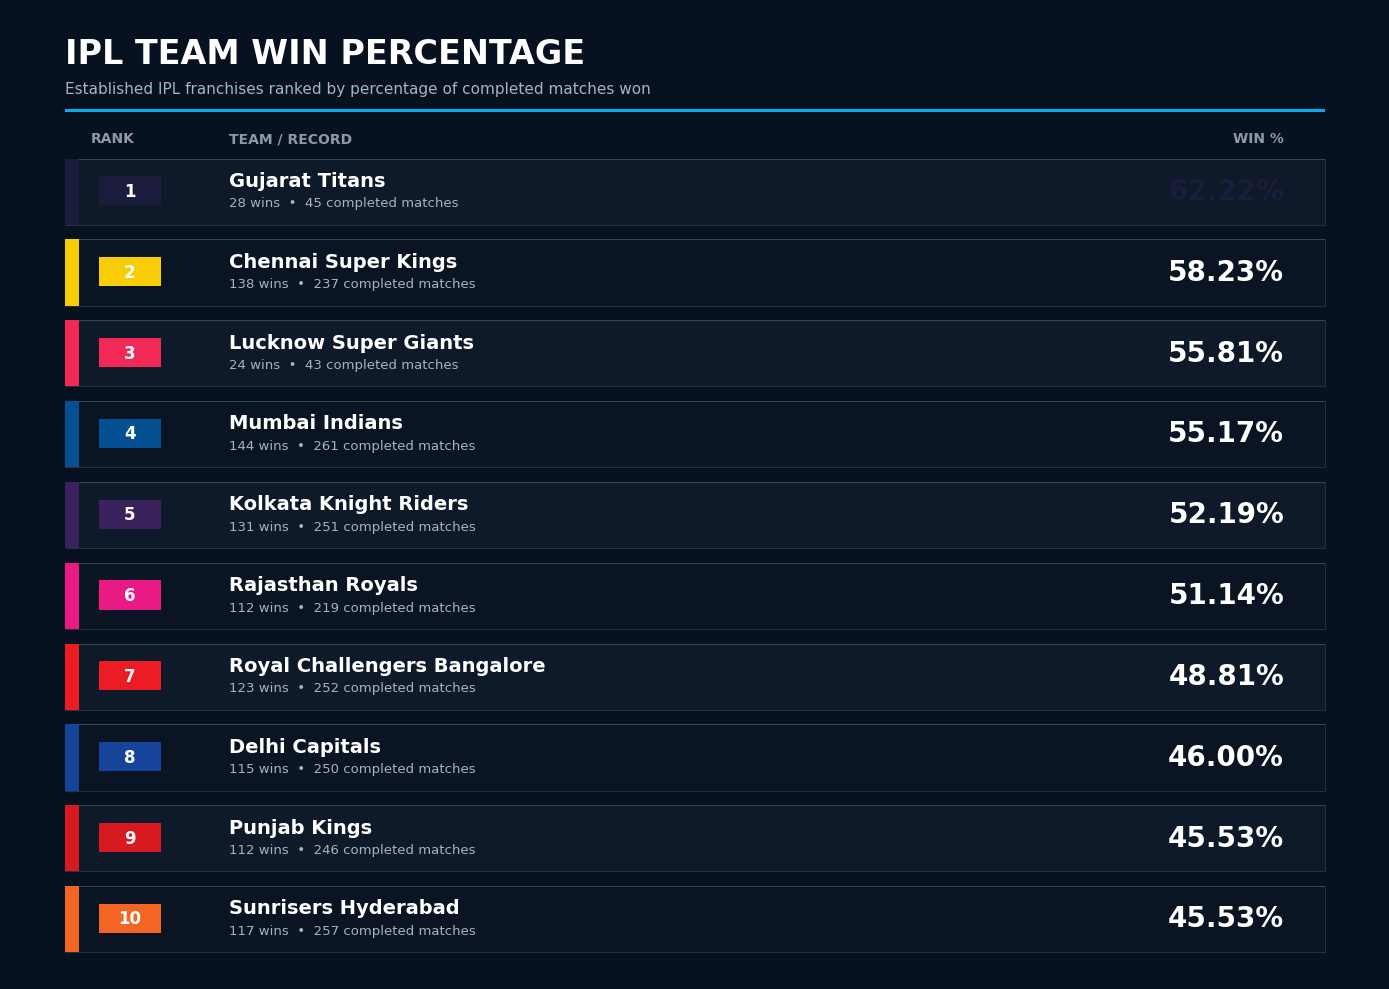

In [140]:
fig, ax = plt.subplots(figsize=(14, 10))

# Broadcast-style dark background
fig.patch.set_facecolor("#07111F")
ax.set_facecolor("#07111F")

ax.set_xlim(0, 1)
ax.set_ylim(0, len(display_win_percentage) + 2)
ax.axis("off")

# Title
ax.text(
    0.04,
    len(display_win_percentage) + 1.45,
    "IPL TEAM WIN PERCENTAGE",
    fontsize=24,
    fontweight="bold",
    color="white",
    va="center"
)

# Subtitle
ax.text(
    0.04,
    len(display_win_percentage) + 1.02,
    "Established IPL franchises ranked by percentage of completed matches won",
    fontsize=11,
    color="#A8B3C2",
    va="center"
)

# Header accent line
ax.add_patch(
    Rectangle(
        (0.04, len(display_win_percentage) + 0.72),
        0.92, 0.04,
        facecolor="#00AEEF", edgecolor="none"
    )
)

# Column headings
ax.text(
    0.075,
    len(display_win_percentage) + 0.35,
    "RANK",
    fontsize=10,
    fontweight="bold",
    color="#8C99A8",
    ha="center"
)

ax.text(
    0.16,
    len(display_win_percentage) + 0.35,
    "TEAM / RECORD",
    fontsize=10,
    fontweight="bold",
    color="#8C99A8"
)

ax.text(
    0.93,
    len(display_win_percentage) + 0.35,
    "WIN %",
    fontsize=10,
    fontweight="bold",
    color="#8C99A8",
    ha="right"
)

# Rows
for i, row in display_win_percentage.iterrows():

    y = len(display_win_percentage) - i - 0.25

    row_colour = "#101C2C" if i % 2 == 0 else "#0B1624"

    # Glossy glass-panel background
    ax.add_patch(
        Rectangle(
            (0.04, y - 0.42),
            0.92, 0.82,
            facecolor=row_colour, alpha=0.78,
            edgecolor="#2A3A4E", linewidth=0.7
        )
    )

    # Highlight along the upper edge creates the glass sheen
    ax.add_patch(
        Rectangle(
            (0.04, y + 0.388), 0.92, 0.012,
            facecolor="white", alpha=0.10, edgecolor="none"
        )
    )

    # Team colour
    team_colour = team_colours.get(
        row["Team"],
        "#00AEEF"
    )

    # Team colour strip
    ax.add_patch(
        Rectangle(
            (0.04, y - 0.42),
            0.01,
            0.82,
            facecolor=team_colour,
            edgecolor="none"
        )
    )

    # Rank badge
    ax.add_patch(
        Rectangle(
            (0.065, y - 0.18),
            0.045, 0.36,
            facecolor=team_colour, edgecolor="none"
        )
    )

    # Rank number
    ax.text(
        0.0875,
        y,
        str(i + 1),
        fontsize=12,
        fontweight="bold",
        color="white",
        ha="center",
        va="center"
    )

    # Team name
    ax.text(
        0.16,
        y + 0.13,
        row["Team"],
        fontsize=14,
        fontweight="bold",
        color="white",
        va="center"
    )

    # Record underneath
    record_text = (
        f'{row["Wins"]} wins  •  '
        f'{row["Matches Played"]} completed matches'
    )

    ax.text(
        0.16,
        y - 0.15,
        record_text,
        fontsize=9.5,
        color="#A8B3C2",
        va="center"
    )

    # Win percentage
    ax.text(
        0.93,
        y,
        f'{row["Win Percentage"]:.2f}%',
        fontsize=20,
        fontweight="bold",
        color=team_colour if i == 0 else "white",
        ha="right",
        va="center"
    )

plt.tight_layout()
plt.show()